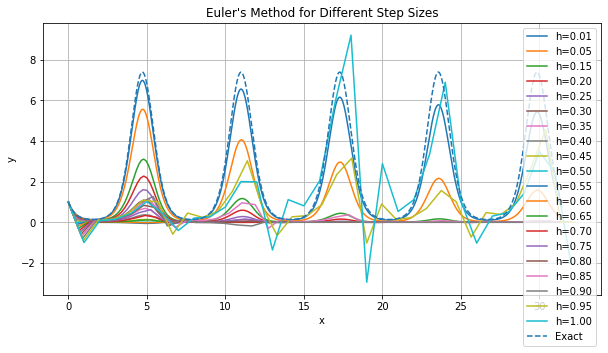

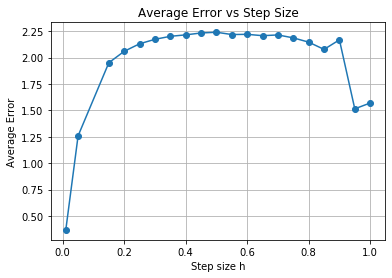

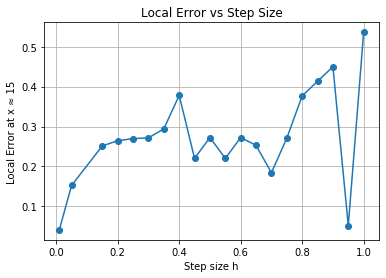


Values of y near x ≈ 15:
h = 0.01 → y ≈ 0.231440
h = 0.05 → y ≈ 0.119869
h = 0.15 → y ≈ 0.020921
h = 0.20 → y ≈ 0.007903
h = 0.25 → y ≈ 0.002662
h = 0.30 → y ≈ 0.000753
h = 0.35 → y ≈ 0.000170
h = 0.40 → y ≈ 0.000026
h = 0.45 → y ≈ 0.000001
h = 0.50 → y ≈ 0.000000
h = 0.55 → y ≈ 0.000000
h = 0.60 → y ≈ -0.000000
h = 0.65 → y ≈ 0.000016
h = 0.70 → y ≈ 0.000005
h = 0.75 → y ≈ 0.001574
h = 0.80 → y ≈ 0.001268
h = 0.85 → y ≈ 0.038863
h = 0.90 → y ≈ 0.002522
h = 0.95 → y ≈ 0.326151
h = 1.00 → y ≈ 0.808593


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def exact_solution(x):
    return np.exp(-2 * np.sin(x))

def f(x, y):
    return -2 * y * np.cos(x)

h_values = [0.01, 0.05, 0.15, 0.2, 0.25]
h_values += list(np.arange(0.30, 1.01, 0.05))

avg_errors = []
local_errors = []
y_at_15 = []

plt.figure(figsize=(10, 5))

for h in h_values:
    x_start = 0
    x_end = 10 * np.pi

    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))

    y_values[0] = 1

    for i in range(1, len(x_values)):
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]

        y_values[i] = y_n + h * f(x_n, y_n)

    y_exact = exact_solution(x_values)

    error = np.abs(y_values - y_exact)
    avg_errors.append(np.mean(error))

    idx_15 = np.argmin(np.abs(x_values - 15))
    y_at_15.append(y_values[idx_15])

    local_errors.append(np.abs(y_values[idx_15] - exact_solution(x_values[idx_15])))

    plt.plot(x_values, y_values, label=f"h={h:.2f}")

x_fine = np.linspace(0, 10*np.pi, 1000)
plt.plot(x_fine, exact_solution(x_fine), linestyle='--', label="Exact")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for Different Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Average Error")
plt.title("Average Error vs Step Size")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(h_values, local_errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Local Error at x ≈ 15")
plt.title("Local Error vs Step Size")
plt.grid(True)
plt.show()

print("\nValues of y near x ≈ 15:")
for h, val in zip(h_values, y_at_15):
    print(f"h = {h:.2f} → y ≈ {val:.6f}")

Explanation: In the first plot, each curve is Euler's method with a different step size. The small h values create curves that follow the exact solution closely. The larger the h values get, the more distorted the curve. This happens because Euler's method accrues error every step.
In the second plot, it shows that the average global error increases with h, which makes sense because Euler's method is first order so the global error scales directly with it.
In the third plot, it shows that when you wnat a single point, with a small h, the value is very close to the exact solution but as h increases, the local error grows quickly.